In [1]:
#rm -rf /kaggle/working/*

# Imports

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Number and data stuff
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random
import shutil
# File Handling
import zipfile
import os
from pathlib import Path
# Plotting
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
# Tensorflow sutff
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import RandomContrast, RandomFlip
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2025-07-06 01:12:27.886250: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751764348.077872      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751764348.140423      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/dogs-vs-cats/test1.zip
/kaggle/input/dogs-vs-cats/train.zip
/kaggle/input/dogs-vs-cats/sampleSubmission.csv


# Problem Statement and Data

Figure out if an image is a cat or dog, 1 = Dog and 0 = cat. The training archive contains 25,000 images of dogs and cats. Apparently machine classifiers can score above 80% accuracy on this task. My goal as a novice is to get as close to 80% as I can. 



# Importing Data

In [3]:
# Extract the zip file
def extract_zip(zip_path, extract_to):
    abs_path = os.path.abspath(extract_to)

    if not os.path.exists(abs_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
        print("Extracted to: ", extract_to)
    else:
        print("Data already loaded for: ", zip_path)

    zip_dir = os.path.basename(zip_path)
    zip_name = os.path.splitext(zip_dir)[0]
    jpg_path = os.path.join(abs_path, zip_name)

    return jpg_path

# Extract your data

train_path = extract_zip('/kaggle/input/dogs-vs-cats/train.zip', './train_ext')
test_path = extract_zip('/kaggle/input/dogs-vs-cats/test1.zip', './test_ext')

Extracted to:  ./train_ext
Extracted to:  ./test_ext


# Data Exploration

## Move Files to class-labeled folders

In [4]:
def move_file_class(parent_dir, class_list, new_dir_name):
    src_class_path = [os.path.join(parent_dir, x) for x in class_list]
    target_class_path = os.path.join(parent_dir, new_dir_name) 
    print(target_class_path)
    #print(src_class_path[0])
    
    if not os.path.exists(target_class_path):
        Path(target_class_path).mkdir(parents=True, exist_ok=True)
        [shutil.move(x, target_class_path) for x in src_class_path]
    else:
        print("Already created the file paths")

    return target_class_path


train_files = [ f for f in os.listdir(train_path) if os.path.isfile(os.path.join(train_path, f))]
cat_files = [x for x in train_files if 'cat' in x]
dog_files = [x for x in train_files if 'dog' in x]
class_len = len(cat_files) + len(dog_files)

train_cat_path = move_file_class(train_path, cat_files, 'cat')
train_dog_path = move_file_class(train_path, dog_files, 'dog')
print("total images: ", class_len)

/kaggle/working/train_ext/train/cat
/kaggle/working/train_ext/train/dog
total images:  25000


## Look at a few images

/kaggle/working/train_ext/train/dog/dog.5350.jpg


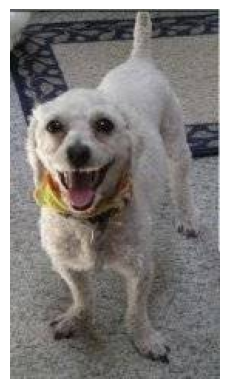

/kaggle/working/train_ext/train/cat/cat.8630.jpg


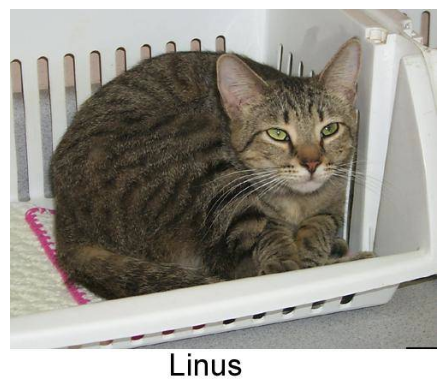

/kaggle/working/train_ext/train/dog/dog.8551.jpg


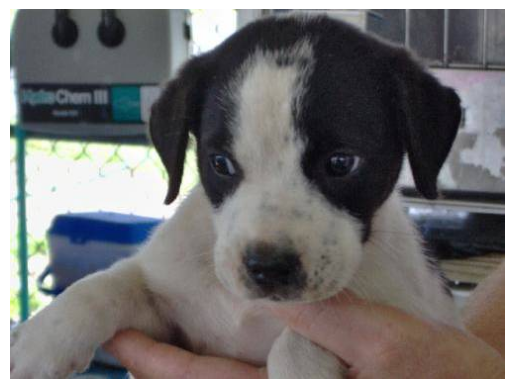

/kaggle/working/train_ext/train/cat/cat.332.jpg


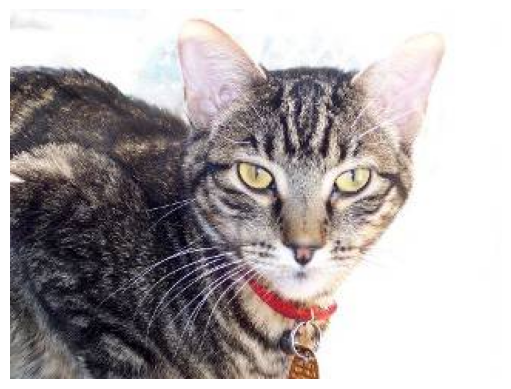

/kaggle/working/train_ext/train/dog/dog.2789.jpg


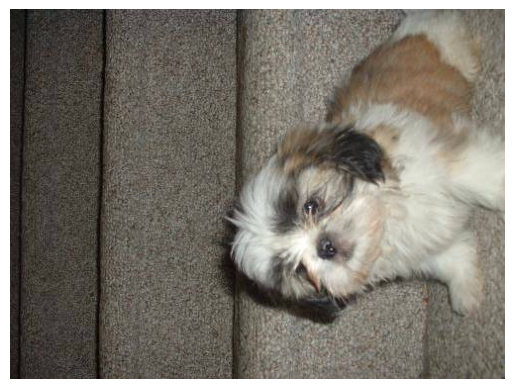

/kaggle/working/train_ext/train/cat/cat.8372.jpg


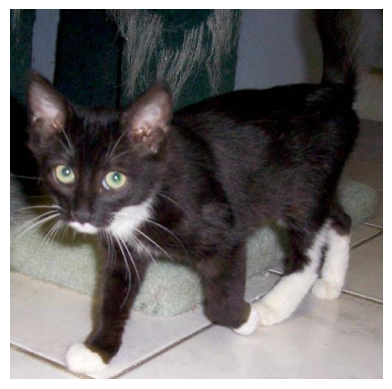

/kaggle/working/train_ext/train/dog/dog.1280.jpg


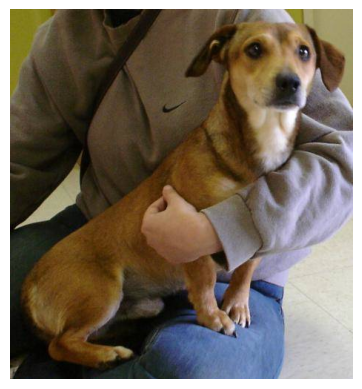

/kaggle/working/train_ext/train/dog/dog.691.jpg


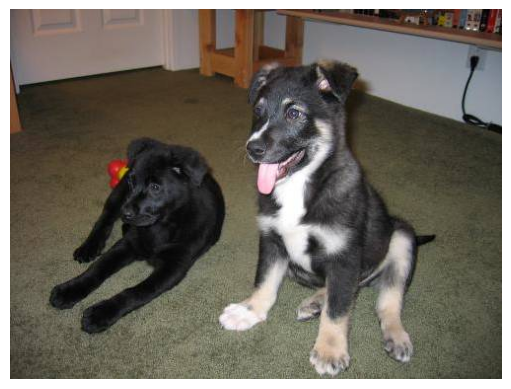

/kaggle/working/train_ext/train/cat/cat.11044.jpg


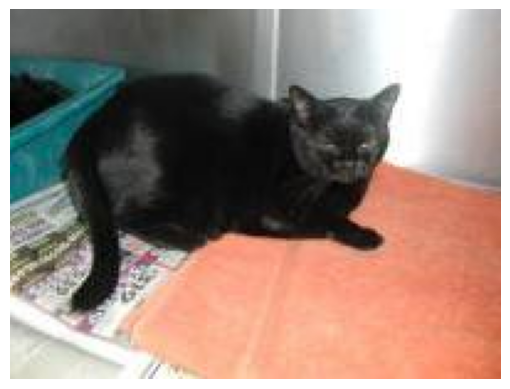

/kaggle/working/train_ext/train/dog/dog.11263.jpg


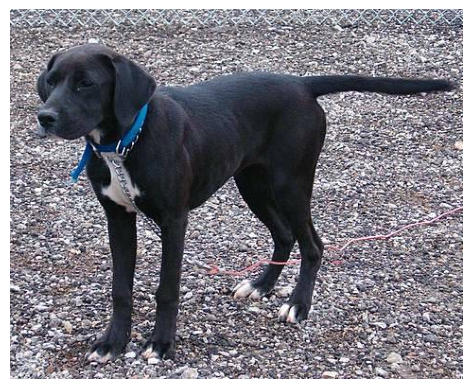

In [5]:
# Randomly select a image to show
cat_files = [os.path.join(train_cat_path,f) for f in os.listdir(train_cat_path) if os.path.isfile(os.path.join(train_cat_path, f))]
dog_files = [os.path.join(train_dog_path,f) for f in os.listdir(train_dog_path) if os.path.isfile(os.path.join(train_dog_path, f))]
files = cat_files + dog_files  

for i in range(10):
    jpg_file = random.choice(files)
    print(jpg_file)    
    
    # Plot Image
    img = mpimg.imread(jpg_file)
    plt.imshow(img)
    plt.axis('off')  # Hide axes
    plt.show()

2 classes: Cats and Dogs


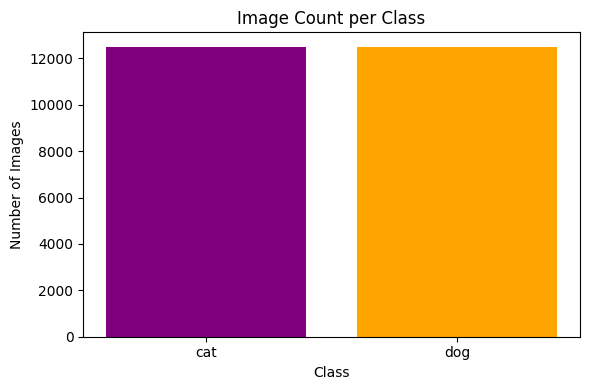

In [6]:
if class_len != len(train_files):
    print("missing classes")
else:
    print("2 classes: Cats and Dogs")
      
# Count
counts = {'cat': len(cat_files), 'dog': len(dog_files)}

# Plot
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=['purple', 'orange'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Count per Class")
plt.tight_layout()
plt.show()

## Image Information

In [7]:
data = []
for jpg in files:
    try:
        img = cv2.imread(jpg)
        height, width, channels = img.shape
        data.append({
                "filename": jpg,
                "height": height,
                "width": width,
                "channels": channels
            })
    except Exception as e:
        print(f"Error reading {jpg}: {e}")

df = pd.DataFrame(data)
print("Head:\n", df.head())
print("\n")
print("Shape:\n ", df.shape)
print("\n")
print("Info:\n")
df.info()
print("\n")
print("Describe:\n", df.describe())

Head:
                                            filename  height  width  channels
0  /kaggle/working/train_ext/train/cat/cat.4481.jpg     290    350         3
1  /kaggle/working/train_ext/train/cat/cat.6319.jpg     421    292         3
2  /kaggle/working/train_ext/train/cat/cat.8410.jpg     500    374         3
3  /kaggle/working/train_ext/train/cat/cat.2839.jpg     375    499         3
4  /kaggle/working/train_ext/train/cat/cat.7809.jpg     320    330         3


Shape:
  (25000, 4)


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  25000 non-null  object
 1   height    25000 non-null  int64 
 2   width     25000 non-null  int64 
 3   channels  25000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 781.4+ KB


Describe:
              height        width  channels
count  25000.000000  25000.00000   25000.0
mean     360.

## Plot Image Info

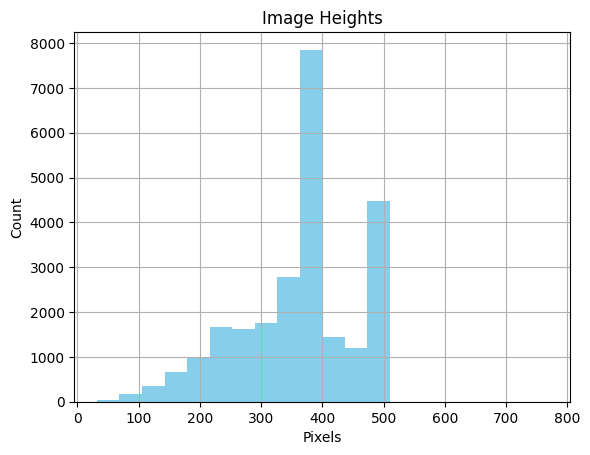

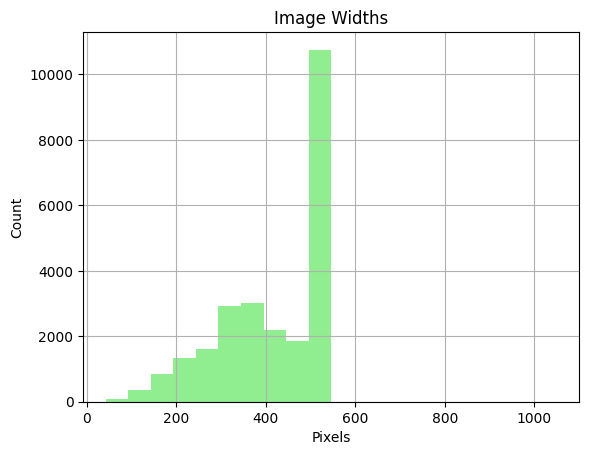

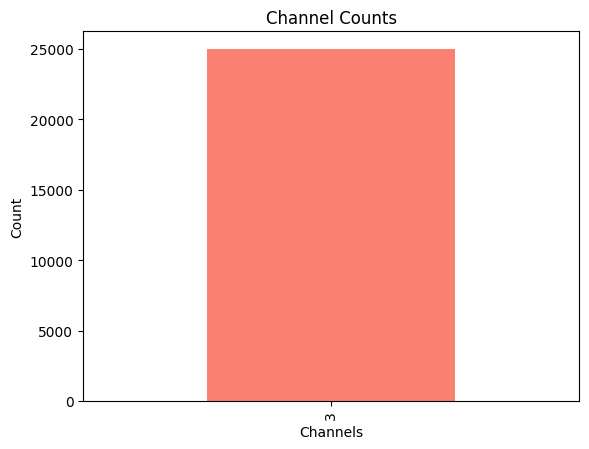

In [8]:
# Plots
bins = 20

df['height'].hist(bins=bins, color='skyblue')
plt.title("Image Heights")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()

df['width'].hist(bins=bins, color='lightgreen')
plt.title("Image Widths")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.show()

df['channels'].value_counts().plot(kind='bar', color='salmon')
plt.title("Channel Counts")
plt.xlabel("Channels")
plt.ylabel("Count")
plt.show()

# Prepare Data Set

## Load Data and create pipeline

In [9]:
# Load training and create validation sets
batch_size = 32
img_height = 180
img_width = 180
train_dir = '/kaggle/working/train_ext/train'

_ds_train = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE

_ds_val = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

ds_train = (
    _ds_train
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

ds_valid = (
    _ds_val
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1751764398.259772      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751764398.260481      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


# Training Model

## Use pre-trained base 

In [10]:
pretrained_base = EfficientNetB0(
    include_top=False,               
    weights='imagenet',             
    input_shape=(img_height, img_width, 3)
)

pretrained_base.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Adding Head and Compiling

In [11]:
model = keras.Sequential([
    # Preprocessing
    RandomFlip('horizontal'), # flip left-to-right
    RandomContrast(0.5), # contrast change by up to 50%
    
    # Base
    pretrained_base,
    
    # Head
    layers.GlobalAveragePooling2D(),  
    layers.BatchNormalization(),      
    layers.Dropout(0.3),
    
    # Larger intermediate layer
    layers.Dense(128, activation='relu'),  
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Gradual reduction
    layers.Dense(64, activation='relu'),   
    layers.Dropout(0.3),
    
    # Final classification layer
    layers.Dense(1, activation='sigmoid'), 
])

initial_learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=initial_learning_rate)


model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy', 'precision', 'recall'],
)

# Model Training & Evaluation

Epoch 1/30


I0000 00:00:1751764421.308501      72 service.cc:148] XLA service 0x7cfe8c0554b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751764421.309350      72 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1751764421.309469      72 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1751764423.413236      72 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/625 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - binary_accuracy: 0.5174 - loss: 1.1949 - precision: 0.5933 - recall: 0.2979   

I0000 00:00:1751764434.574244      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 69ms/step - binary_accuracy: 0.9474 - loss: 0.1438 - precision: 0.9576 - recall: 0.9358 - val_binary_accuracy: 0.9878 - val_loss: 0.0348 - val_precision: 0.9906 - val_recall: 0.9855 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - binary_accuracy: 0.9795 - loss: 0.0575 - precision: 0.9816 - recall: 0.9777 - val_binary_accuracy: 0.9884 - val_loss: 0.0300 - val_precision: 0.9921 - val_recall: 0.9851 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - binary_accuracy: 0.9817 - loss: 0.0492 - precision: 0.9829 - recall: 0.9807 - val_binary_accuracy: 0.9888 - val_loss: 0.0290 - val_precision: 0.9902 - val_recall: 0.9879 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - binary_accuracy: 0.9844 - loss: 0.0449 - precision: 0.9852 - recall: 0.9838 - val_binary_accuracy: 0.9878 - val_loss: 0.0307 - val_precision: 0.9902 - val_recall: 0.9859 - learning_rate: 0.0010
Epoch 5/30


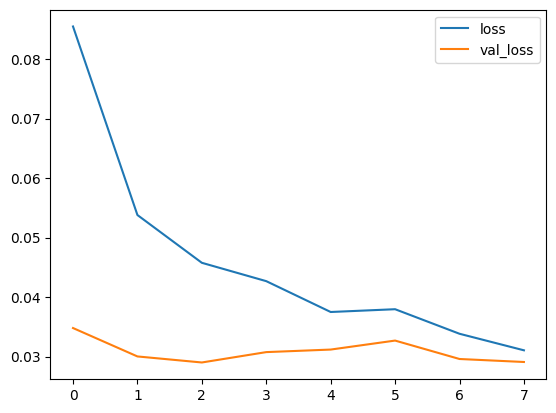

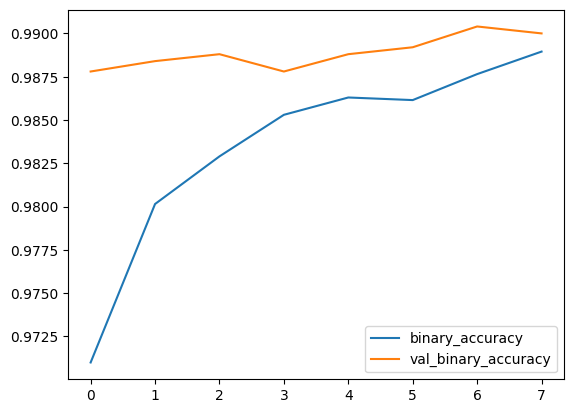

In [12]:
# Callbacks to schedule and/or stop learning
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-7
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
    verbose=1,
    callbacks=[reduce_lr, early_stopping]
)

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();